# 03 — The DiD over all 26 pairs: the feature-based estimator (02) run per site with the kNN donors (01)

Executes `02_DiD_estimator_feature09.ipynb`'s source (the feature-based code + 5 declaration edits) for all 26
treatment sites under **each kNN donor tree** built by `06_embed_knn_matching.ipynb`
(`EMBED_DID_BASE=embeddings_knn_s1` and `..._s2`; `EMBED_DID_SITE` per site). Each tree's
matching table was built from ONE sensor's similarity, so only that sensor's rows are
kept from each run (the other sensor's output uses mismatched donors by construction and
is discarded). Estimator, code, representation identical to notebook 10 — **donor
selection is the only manipulated variable**.

Same display-only adjustments as notebook 10 (`plt.show` no-op, stdout buffered).


> **SWAP (2026-08-15, logged):** 01 and 02 exchanged numbers so numbering equals execution order (donor selection runs before the estimator): the estimator is now `02_DiD_estimator_feature09.ipynb`, donor matching is `01_knn_donor_matching.ipynb`. The load path in this notebook was updated accordingly. Path edit only — NOT re-executed (outputs unchanged).

## Setup

Loads the list of 26 treated sites and reads the **source code of `02_DiD_estimator_feature09.ipynb`**
into a string. The printed character count is the proof of what will be executed below: the feature-based
estimator, in full, not a rewrite. Nothing runs yet.

In [1]:
import io
import json
import os
from contextlib import redirect_stdout
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, wilcoxon

ROOT = Path("/data/wang/junh/githubs/latent-synthetic-control")
ED = ROOT / "Satellite" / "notebooks" / "embed_DiD"
EMB = ROOT / "Satellite" / "data" / "embeddings"

C_CONTROL, C_TREAT, C_ACCENT = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 10,
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "figure.titlesize": 12,
})

TREES = {"sentinel1": ROOT / "Satellite" / "data" / "embeddings_knn_s1",
         "sentinel2": ROOT / "Satellite" / "data" / "embeddings_knn_s2"}

her_table = pd.read_csv(EMB / "finals" / "site_matching_table.csv")
treatments = sorted(her_table["treatment_site_id"].astype(str).unique())

nb09 = json.load(open(ED / "02_DiD_estimator_feature09.ipynb"))
src09 = "".join(next(c for c in nb09["cells"] if c["cell_type"] == "code")["source"])
print(len(treatments), "sites |", len(src09), "chars of the feature-based (adapted) code")

26 sites | 47517 chars of the feature-based (adapted) code


## Run the feature-based code: 26 sites × 2 donor trees

For each sensor folder (`embeddings_knn_s1`, `embeddings_knn_s2`) and each of the 26 sites:
set `EMBED_DID_SITE` + `EMBED_DID_BASE`, execute the feature-based code — **52 runs of the estimator**. Each
run reads that site's 10 kNN donors from the folder's `site_matching_table.csv`, computes
effect = treated change − counterfactual change (the feature-based step 9), and writes the site's
`counterfactual_feature_summary.csv`. **`failures: []` is the check that matters**: every
site ran to completion; nothing was skipped.

In [2]:
_show = plt.show
plt.show = lambda *a, **k: None
failed = []
for sensor, base in TREES.items():
    for sid in treatments:
        os.environ["EMBED_DID_BASE"] = str(base)
        os.environ["EMBED_DID_SITE"] = sid
        try:
            with redirect_stdout(io.StringIO()):
                exec(src09, {"__name__": "__main__"})
        except Exception as e:
            failed.append((sensor, sid, repr(e)))
        finally:
            plt.close("all")
    print(f"{sensor} tree: done ({base.name})")
plt.show = _show
os.environ.pop("EMBED_DID_BASE", None)
os.environ.pop("EMBED_DID_SITE", None)
print("failures:", failed)
assert not failed

sentinel1 tree: done (embeddings_knn_s1)


sentinel2 tree: done (embeddings_knn_s2)
failures: []


## Aggregate (keep only the sensor each tree was built for)

Gathers the 52 per-site files into one table → `embed_knn_effects.csv`. The printed shape is
an arithmetic completeness check: 26 sites × 768 embedding dimensions × 2 sensors =
**39,936 rows**, split exactly 19,968 per sensor. Any missing site or dimension would make
these counts wrong.

In [3]:
parts = []
for sensor, base in TREES.items():
    for sid in treatments:
        df = pd.read_csv(base / "test" / sid / "counterfactual_feature_summary.csv")
        assert len(df) == 768 * 2, (sensor, sid, len(df))
        parts.append(df.query("sensor == @sensor"))
knn_effects = pd.concat(parts, ignore_index=True)
knn_effects.to_csv(ED / "embed_knn_effects.csv", index=False)
print("aggregated:", knn_effects.shape)
print(knn_effects.groupby("sensor").size().rename("rows").to_string())

aggregated: (39936, 21)
sensor
sentinel1    19968
sentinel2    19968


## Per-site norms under kNN donors, joined with the covariate-donor arm

**Definitions (our summaries — the collaborator reports per-band effects, no norms; see note
below).** Each site's DiD output here is a 768-dimensional effect vector; both quantities
collapse a 768-vector to its Euclidean length ‖v‖ = √(Σ vᵢ²):

- **`effect_norm`** = ‖effect vector‖ — the overall magnitude of change attributed to the
  landslide, all embedding dimensions combined (no sign/direction, magnitude only).
- **`pre_imbalance_norm`** = ‖e_before(treated) − mean e_before(donors)‖ — the distance
  between the real site and its fake twin **before** the storm: pure match quality,
  uncontaminated by any effect (before-period data only). A perfect twin would give 0.
  It is the embedding-space analog of "pre-treatment fit" (RMSPE) in the synthetic-control
  literature: Abadie's papers judge every synthetic control by exactly this "how far is the
  fake from the real, before treatment" distance, and it's the denominator of their standard
  placebo statistic.

Norms are comparable across sites **within one sensor only** (S1 and S2 are different
spaces; embedding units have no physical meaning).

| quantity | S1 | S2 | meaning |
|---|---|---|---|
| pre-imbalance, feature-based donors | 5.12 | 2.91 | how far the counterfactual sits from the treated site before the storm |
| pre-imbalance, kNN donors | 3.40 | 1.73 | same, with the kNN donors — much closer |
| effect norm, feature-based donors | 4.47 | 2.58 | measured effect magnitude |
| effect norm, kNN donors | 3.33 | 2.07 | smaller — because less donor mismatch is being counted as "effect" |

Note on the "feature-based donors" rows: all four rows are OUR norm summaries, computed in the
same embedding space. "Feature-based donors" = the donor table shipped with the dataset (the
output of the collaborator's covariate matching, used here as data — the baseline
condition). "kNN donors" = the table from notebook 01. The only difference between rows is
which donor table fed the estimator: same space, same summary, one variable changed —
that is what makes the rows comparable. Nothing in this table is a number computed by the
collaborator.

Read top-down: better donors → tighter pre-period match → smaller measured effects. The
drop in effect norm is not lost signal; it is the removal of fake signal that was really
pre-existing mismatch.

In [4]:
emb = pd.read_csv(EMB / "site_embeddings.csv")
ecols = [c for c in emb.columns if c.startswith("emb_")]
emb_idx = emb.set_index(["site_id", "sensor", "period"])[ecols]

rows = []
for sensor, base in TREES.items():
    knn_t = pd.read_csv(base / "finals" / "site_matching_table.csv")
    donors_by_t = knn_t.groupby("treatment_site_id")["counterfactual_site_id"].apply(list)
    for sid in treatments:
        sub = (knn_effects.query("treatment_site_id == @sid and sensor == @sensor")
               .set_index("band").loc[ecols])
        donors = donors_by_t[sid]
        pre_gap = (emb_idx.loc[(sid, sensor, "before")].to_numpy()
                   - emb_idx.loc[[(d, sensor, "before") for d in donors]].mean(axis=0).to_numpy())
        rows.append({"site": sid, "sensor": sensor,
                     "effect_norm": float(np.linalg.norm(sub["mean_adjusted_effect"])),
                     "pre_imbalance_norm": float(np.linalg.norm(pre_gap))})
knn_norms = pd.DataFrame(rows)
knn_norms.to_csv(ED / "embed_knn_site_norms.csv", index=False)

cov_norms = pd.read_csv(ED / "same_repr" / "embed_did_site_norms.csv")  # REORG EDIT 2026-08-15
both = cov_norms.merge(knn_norms, on=["site", "sensor"], suffixes=("_covariate", "_knn"))
print(both.groupby("sensor")[["pre_imbalance_norm_covariate", "pre_imbalance_norm_knn",
                              "effect_norm_covariate", "effect_norm_knn"]]
      .agg(["mean", "median"]).round(3).T.to_string())

sensor                               sentinel1  sentinel2
pre_imbalance_norm_covariate mean        5.115      2.913
                             median      5.130      2.711
pre_imbalance_norm_knn       mean        3.398      1.729
                             median      3.313      1.637
effect_norm_covariate        mean        4.468      2.582
                             median      4.311      2.448
effect_norm_knn              mean        3.332      2.066
                             median      2.896      1.940


## Comparison: does similarity-based donor selection tighten the counterfactual?

Per sensor: the per-site % reduction in pre-imbalance (median / min / max — the min shows
even the worst site improved), a **paired Wilcoxon signed-rank test** across the 26 sites
(p = 2.98e-8 is the smallest value a 26-pair test can produce — every pair moved in the
same direction, i.e. *all* 26 sites improved), and the Spearman rank correlation of effect
norms between donor sets (ρ ≈ 0.5–0.6: the two donor sets still rank sites similarly, so
switching donors refines the measurement rather than telling an unrelated story).

sentinel1: pre-imbalance drop median +32.9% (min +8.2%, max +56.2%), Wilcoxon p=2.98e-08 | effect-norm rank corr covariate-vs-knn donors rho=+0.52 (p=0.007)
sentinel2: pre-imbalance drop median +38.0% (min +15.9%, max +60.3%), Wilcoxon p=2.98e-08 | effect-norm rank corr covariate-vs-knn donors rho=+0.58 (p=0.002)


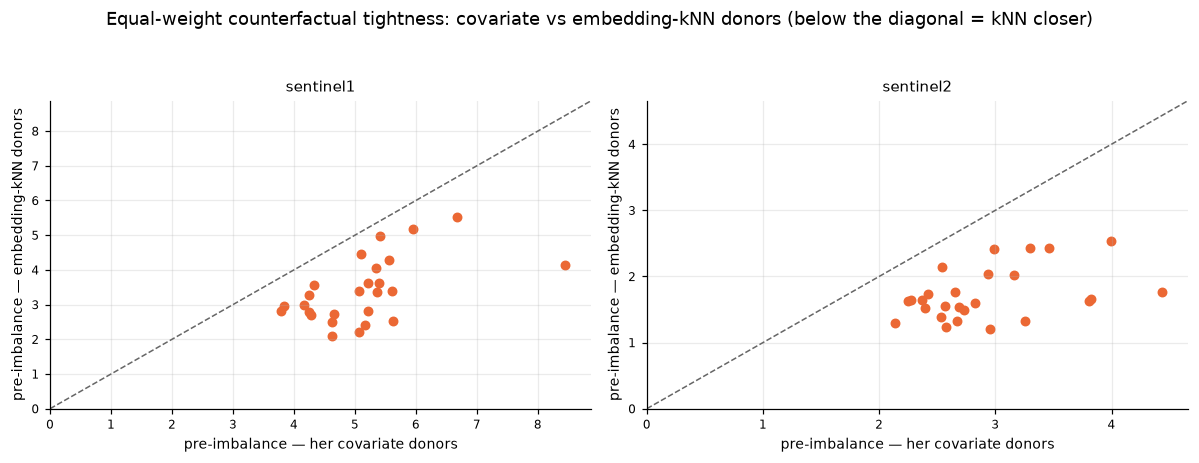

In [5]:
for sensor in ("sentinel1", "sentinel2"):
    b = both.query("sensor == @sensor")
    drop = 100 * (1 - b["pre_imbalance_norm_knn"] / b["pre_imbalance_norm_covariate"])
    w = wilcoxon(b["pre_imbalance_norm_covariate"], b["pre_imbalance_norm_knn"])
    rho, p = spearmanr(b["effect_norm_covariate"], b["effect_norm_knn"])
    print(f"{sensor}: pre-imbalance drop median {drop.median():+.1f}% "
          f"(min {drop.min():+.1f}%, max {drop.max():+.1f}%), Wilcoxon p={w.pvalue:.2e} | "
          f"effect-norm rank corr covariate-vs-knn donors rho={rho:+.2f} (p={p:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, sensor in zip(axes, ("sentinel1", "sentinel2")):
    b = both.query("sensor == @sensor")
    lim = [0, max(b["pre_imbalance_norm_covariate"].max(), b["pre_imbalance_norm_knn"].max()) * 1.05]
    ax.scatter(b["pre_imbalance_norm_covariate"], b["pre_imbalance_norm_knn"],
               color=C_TREAT, s=30)
    ax.plot(lim, lim, color="0.4", lw=1, ls="--")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("pre-imbalance — the feature-based covariate donors")
    ax.set_ylabel("pre-imbalance — embedding-kNN donors")
    ax.set_title(sensor)
fig.suptitle("Equal-weight counterfactual tightness: covariate vs embedding-kNN donors "
             "(below the diagonal = kNN closer)", y=1.04)
plt.tight_layout(); plt.show()

## Head-to-head vs the original setup: do the two analyses rank sites the same?

(Merged 2026-08-15 from a former standalone rank-comparison notebook — NOT the current notebook 04, which is the tokenizer-space arm.) Above, both conditions were embedding-based — a
controlled comparison of donor choices. This section is the external comparison: the
**collaborator's original setup** (11 band features + feature-based donors, reproduced from
cached data) vs **this experiment** (embeddings + kNN donors). Their magnitudes live in
incomparable units, so only **ranks** can be compared: does each analysis agree on *which*
of the 26 sites were hit hardest? Each point = one site, plotted by its effect-magnitude
rank under the two analyses (1 = largest); diagonal = agreement.

- *Original-setup magnitude*: per-band equal-weight DiD effect (treated change − mean donor
  change, the feature-based pixelwise convention, shipped donor table), z-scored across the 26 sites per
  band (ddof=1), then the L2 norm over the sensor's bands.
- *This experiment's magnitude*: `effect_norm` from `embed_knn_site_norms.csv` (written above).


sentinel1: rho = +0.042, p = 0.838
sentinel2: rho = +0.078, p = 0.706


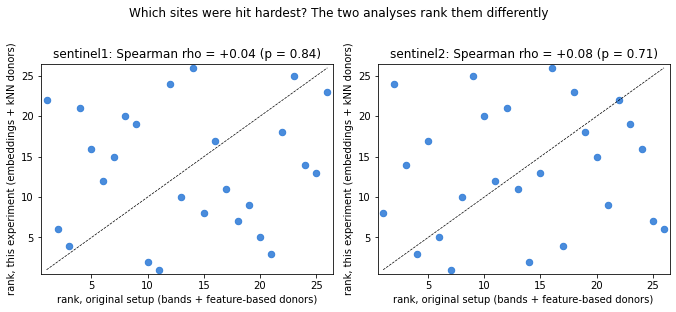

saved: /data/wang/junh/githubs/latent-synthetic-control/Satellite/notebooks/embed_DiD/rank_comparison_original_vs_knn.png


In [1]:
# Head-to-head rank comparison (merged from notebook 04) — self-contained
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

_ROOT = Path("/data/wang/junh/githubs/latent-synthetic-control")
_NBK = _ROOT / "Satellite" / "notebooks"
_ED = _NBK / "embed_DiD"
_BANDS = {"sentinel1": ["VV", "VH", "VV_minus_VH"],
          "sentinel2": ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI"]}

_feats = pd.read_csv(_NBK / "site_band_features.csv")
_ch = _feats[_feats.period == "change"].set_index(["site_id", "sensor"])
_feat_map = (pd.read_csv(_ROOT / "Satellite" / "data" / "embeddings" / "finals" / "site_matching_table.csv")
             .groupby("treatment_site_id")["counterfactual_site_id"].apply(list).to_dict())
_sites = sorted(_feat_map)
_knn_norms = (pd.read_csv(_ED / "embed_knn_site_norms.csv")
              .set_index(["site", "sensor"])["effect_norm"])

def _original_setup_mags(sensor):
    rows = {t: (_ch.loc[(t, sensor), _BANDS[sensor]].astype(float)
                - np.mean([_ch.loc[(d, sensor), _BANDS[sensor]].astype(float).values
                           for d in dons], axis=0))
            for t, dons in _feat_map.items()}
    df = pd.DataFrame(rows).T
    z = (df - df.mean()) / df.std(ddof=1)
    return np.sqrt((z ** 2).sum(axis=1)).loc[_sites]

_fig, _axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
for _ax, _s in zip(_axes, ["sentinel1", "sentinel2"]):
    _a = _original_setup_mags(_s)
    _b = pd.Series({t: _knn_norms.loc[(t, _s)] for t in _sites})
    _rho, _p = spearmanr(_a, _b)
    _ax.scatter(_a.rank(ascending=False), _b.rank(ascending=False),
                s=42, color="#2a78d6", alpha=0.85)
    _ax.plot([1, 26], [1, 26], color="k", lw=0.7, ls="--")
    _ax.set_xlabel("rank, original setup (bands + feature-based donors)")
    _ax.set_ylabel("rank, this experiment (embeddings + kNN donors)")
    _ax.set_title(f"{_s}: Spearman rho = {_rho:+.2f} (p = {_p:.2f})")
    _ax.set_xlim(0.5, 26.5); _ax.set_ylim(0.5, 26.5)
    print(f"{_s}: rho = {_rho:+.3f}, p = {_p:.3f}")
_fig.suptitle("Which sites were hit hardest? The two analyses rank them differently", y=1.02)
plt.tight_layout()
plt.savefig(_ED / "rank_comparison_original_vs_knn.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved:", _ED / "rank_comparison_original_vs_knn.png")

## Reading

- `pre_imbalance_norm` is expected to drop mechanically — kNN picks donors to be close in
  exactly this space — so the drop's *size* is the informative part: it bounds how much
  of the feature-based covariate-matched donors' mismatch was avoidable by better selection alone,
  before any weight estimation.
- The effect-norm rank correlation between the two donor sets says whether the measured
  per-site effects are robust to who the donors are. Low correlation would mean the
  "effect" is substantially donor-noise — a caution that applies to BOTH arms and
  motivates placebo calibration.
- Follow-up, DONE (2026-08-16; comparison side corrected 2026-08-17):
  `04_tokenizer_space_pipeline` — a fully coherent arm where donor selection,
  equal-weight estimation, AND decoding all happen in one latent space (the TerraMind
  tokenizer's). It decodes the estimator's own counterfactuals and compares them against
  the collaborator's actual notebook-09 counterfactual (her donors, her image-level
  procedure, gate-verified against her shipped treatment_0001 outputs): effects agree in
  pattern, not level (S1 r ≈ +0.68 with nRMSE 1.0–1.3; S2 r +0.49…+0.82 over a
  decoder-floor offset). Note that arm's latent is NOT this notebook's 768-d space —
  this experiment's own information-preservation argument remains the linear probe
  (R² 0.80–1.00).
